In [ ]:
# Install dependencies when running in a fresh Colab/Jupyter environment.
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "pyspark", "requests", "pandas", "numpy", "scikit-learn", "matplotlib"
])
print("Dependencies installed.")


Dependencies installed.


In [ ]:
import json
import time
from datetime import datetime
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.functions import vector_to_array
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

spark = SparkSession.builder.appName("ai-climate-citation-prediction-improved").getOrCreate()
spark.conf.set("spark.sql.shuffle.partitions", "8")
print("PySpark:", __import__('pyspark').__version__)
print("Spark parallelism:", spark.sparkContext.defaultParallelism)

PySpark: 4.0.4
Spark parallelism: 2


## 2. Configuration

In [ ]:
YOUR_EMAIL = "fahmidul.cse.20220104103@aust.edu"
API_KEY = ""  # optional

CONCEPT_MODE = "AND"  # AND = AI-for-climate corpus; OR = broader union
PUBLICATION_YEARS = "2020-2024"
MAX_RECORDS = None
RUN_COLLECTION = True  # Set False after the CSV has been created to avoid re-downloading data.
TOP_PERCENT_HIGH_IMPACT = 0.10

# Temporal experiment design
TRAIN_YEARS = [2020, 2021]
VALIDATION_YEARS = [2022]
TEST_YEARS = [2023, 2024]

# Reproducibility / runtime
SEED = 42
N_TREES = 80
RF_MAX_DEPTH = 6
GBT_MAX_ITER = 35
GBT_MAX_DEPTH = 5

TOPIC_IDS = {
    "ai": "C154945302",
    "climate": "C39432304",
}

RAW_CSV_PATH = "openalex_ai_climate_raw_improved.csv"

## 3. Collect AI + climate papers from OpenAlex

In [ ]:
BASE_URL = "https://api.openalex.org/works"
FIELDS = [
    "id", "title", "publication_year", "publication_date",
    "primary_location", "authorships", "open_access", "topics",
    "cited_by_count", "counts_by_year",
]

def build_filter():
    if CONCEPT_MODE == "AND":
        topic_filter = f"concepts.id:{TOPIC_IDS['ai']},concepts.id:{TOPIC_IDS['climate']}"
    elif CONCEPT_MODE == "OR":
        topic_filter = f"concepts.id:{TOPIC_IDS['ai']}|{TOPIC_IDS['climate']}"
    else:
        raise ValueError("CONCEPT_MODE must be 'AND' or 'OR'.")
    return f"{topic_filter},publication_year:{PUBLICATION_YEARS},type:article"

def extract_row(work):
    authorships = work.get("authorships") or []
    institutions, countries = set(), set()

    for author in authorships:
        for inst in (author.get("institutions") or []):
            if inst.get("id"):
                institutions.add(inst["id"])
            if inst.get("country_code"):
                countries.add(inst["country_code"])

    oa = work.get("open_access") or {}
    primary = work.get("primary_location") or {}
    venue = (primary.get("source") or {}).get("display_name") or "unknown"

    topics = work.get("topics") or []
    topic_names = "; ".join(
        t.get("display_name", "").strip()
        for t in topics[:5]
        if t.get("display_name")
    )

    counts_by_year = work.get("counts_by_year") or []
    pub_year = work.get("publication_year")

    # Calendar-year signal only; this is NOT an exact first-12-month window.
    early_calendar_year_citations = sum(
        int(e.get("cited_by_count", 0) or 0)
        for e in counts_by_year
        if pub_year is not None and e.get("year") == pub_year
    )

    return {
        "openalex_id": work.get("id"),
        "title": work.get("title"),
        "publication_year": pub_year,
        "publication_date": work.get("publication_date"),
        "venue": venue,
        "num_authors": len(authorships),
        "num_institutions": len(institutions),
        "num_countries": len(countries),
        "countries": "; ".join(sorted(countries)),
        "open_access_status": oa.get("oa_status") or "unknown",
        "is_oa": oa.get("is_oa"),
        "topics": topic_names,
        "cited_by_count_total": work.get("cited_by_count"),
        "citations_by_year_json": json.dumps(counts_by_year),
        "early_calendar_year_citations": early_calendar_year_citations,
    }

def fetch_all(max_retries=5):
    session = requests.Session()
    cursor = "*"
    rows = []

    while True:
        params = {
            "filter": build_filter(),
            "per-page": 200,
            "cursor": cursor,
            "select": ",".join(FIELDS),
        }
        if API_KEY:
            params["api_key"] = API_KEY

        for attempt in range(max_retries):
            try:
                resp = session.get(BASE_URL, params=params, timeout=60)
                if resp.status_code == 200:
                    break
                if resp.status_code in (429, 500, 502, 503, 504):
                    wait = min(30, 2 ** attempt)
                    print(f"OpenAlex HTTP {resp.status_code}; retrying in {wait}s...")
                    time.sleep(wait)
                    continue
                print("Request URL:", resp.url)
                print("Response:", resp.text[:1000])
                resp.raise_for_status()
            except requests.RequestException:
                if attempt == max_retries - 1:
                    raise
                wait = min(30, 2 ** attempt)
                print(f"Request failed; retrying in {wait}s...")
                time.sleep(wait)
        else:
            raise RuntimeError("OpenAlex request failed after retries.")

        data = resp.json()
        results = data.get("results", [])
        if not results:
            break

        rows.extend(extract_row(work) for work in results)
        print(f"[{datetime.now().isoformat(timespec='seconds')}] fetched {len(rows):,}")

        if MAX_RECORDS is not None and len(rows) >= MAX_RECORDS:
            rows = rows[:MAX_RECORDS]
            break

        next_cursor = (data.get("meta") or {}).get("next_cursor")
        if not next_cursor or next_cursor == cursor:
            break
        cursor = next_cursor
        time.sleep(0.1)

    return pd.DataFrame(rows)

# First run: collect fresh data. Later runs: set RUN_COLLECTION=False and reuse the CSV.
if RUN_COLLECTION or not Path(RAW_CSV_PATH).exists():
    raw_df = fetch_all()
    if raw_df.empty:
        raise RuntimeError("OpenAlex returned no records. Check the filter, network, or API settings.")
    raw_df.to_csv(RAW_CSV_PATH, index=False)
    print("Saved", f"{len(raw_df):,}", "rows to", RAW_CSV_PATH)
else:
    print("Using existing:", RAW_CSV_PATH)


[2026-09-06T07:45:19] fetched 200
[2026-09-06T07:45:20] fetched 400
[2026-09-06T07:45:21] fetched 600
[2026-09-06T07:45:21] fetched 800
[2026-09-06T07:45:22] fetched 1,000
[2026-09-06T07:45:23] fetched 1,200
[2026-09-06T07:45:23] fetched 1,400
[2026-09-06T07:45:24] fetched 1,600
[2026-09-06T07:45:25] fetched 1,800
[2026-09-06T07:45:26] fetched 2,000
[2026-09-06T07:45:26] fetched 2,200
[2026-09-06T07:45:27] fetched 2,400
[2026-09-06T07:45:27] fetched 2,600
[2026-09-06T07:45:28] fetched 2,800
[2026-09-06T07:45:28] fetched 3,000
[2026-09-06T07:45:29] fetched 3,200
[2026-09-06T07:45:30] fetched 3,400
[2026-09-06T07:45:30] fetched 3,600
[2026-09-06T07:45:31] fetched 3,800
[2026-09-06T07:45:31] fetched 4,000
[2026-09-06T07:45:32] fetched 4,200
[2026-09-06T07:45:33] fetched 4,400
[2026-09-06T07:45:33] fetched 4,600
[2026-09-06T07:45:34] fetched 4,800
[2026-09-06T07:45:34] fetched 5,000
[2026-09-06T07:45:35] fetched 5,200
[2026-09-06T07:45:36] fetched 5,400
[2026-09-06T07:45:36] fetched 5,600


## 4. Load and clean the OpenAlex dataset

In [ ]:
from pathlib import Path

existing = Path(RAW_CSV_PATH)
if not existing.exists():
    raise FileNotFoundError(
        f"Dataset not found at {existing.resolve()}. "
        "Run the collection cell first or set RAW_CSV_PATH to an existing OpenAlex CSV."
    )

sdf = spark.read.csv(
    str(existing),
    header=True,
    inferSchema=False,
    quote='"',
    escape='"',
    multiLine=True,
)

int_cols = [
    "publication_year", "cited_by_count_total", "num_authors",
    "num_institutions", "num_countries", "early_calendar_year_citations"
]
for c in int_cols:
    sdf = sdf.withColumn(c, F.expr(f"try_cast(`{c}` AS INT)"))

sdf = sdf.withColumn("is_oa", F.expr("try_cast(is_oa AS BOOLEAN)"))

before = sdf.count()

sdf = (
    sdf
    .dropDuplicates(["openalex_id"])
    .filter(
        F.col("openalex_id").isNotNull()
        & F.col("publication_year").isNotNull()
        & F.col("cited_by_count_total").isNotNull()
    )
    .fillna({
        "venue": "unknown",
        "open_access_status": "unknown",
        "topics": "",
        "is_oa": False,
        "num_authors": 0,
        "num_institutions": 0,
        "num_countries": 0,
        "early_calendar_year_citations": 0,
    })
)

after = sdf.count()

if after == 0:
    raise ValueError("No usable rows remain after cleaning.")

print(f"Input rows: {before:,}")
print(f"Rows after cleaning: {after:,}")
print(f"Removed: {before - after:,}")
sdf.groupBy("publication_year").count().orderBy("publication_year").show()


Input rows: 62,072
Rows after cleaning: 62,072
Removed: 0
+----------------+-----+
|publication_year|count|
+----------------+-----+
|            2020|10563|
|            2021|11098|
|            2022|11036|
|            2023|11782|
|            2024|17593|
+----------------+-----+



## 5. Feature engineering — strict metadata vs early citation signal

In [ ]:
sdf = (
    sdf
    .withColumn("is_oa_int", F.when(F.col("is_oa") == True, 1).otherwise(0))
    .withColumn("num_topics", F.when(F.trim(F.col("topics")) == "", 0)
                .otherwise(F.size(F.split(F.col("topics"), ";"))))
    .withColumn("international_collab", F.when(F.col("num_countries") > 1, 1).otherwise(0))
    .withColumn("authors_per_institution",
                F.when(F.col("num_institutions") > 0,
                       F.col("num_authors") / F.col("num_institutions"))
                .otherwise(F.col("num_authors")))
)

metadata_features = [
    "num_authors", "num_institutions", "num_countries",
    "international_collab", "authors_per_institution", "is_oa_int",
    "num_topics", "venue", "open_access_status"
]

early_signal_features = metadata_features + ["early_calendar_year_citations"]

print("PRIMARY (metadata-only):", metadata_features)
print("SECONDARY (+ early citation signal):", early_signal_features)

PRIMARY (metadata-only): ['num_authors', 'num_institutions', 'num_countries', 'international_collab', 'authors_per_institution', 'is_oa_int', 'num_topics', 'venue', 'open_access_status']
SECONDARY (+ early citation signal): ['num_authors', 'num_institutions', 'num_countries', 'international_collab', 'authors_per_institution', 'is_oa_int', 'num_topics', 'venue', 'open_access_status', 'early_calendar_year_citations']


## 6. Create a deterministic top-10% high-impact label

In [ ]:
# Exact top-10% within each publication-year cohort.
# A stable OpenAlex ID tie-breaker makes the label deterministic.
year_w = Window.partitionBy("publication_year")
rank_w = Window.partitionBy("publication_year").orderBy(
    F.col("cited_by_count_total").desc(),
    F.col("openalex_id").asc(),
)

sdf = (
    sdf
    .withColumn("year_n", F.count(F.lit(1)).over(year_w))
    .withColumn("rank_in_year", F.row_number().over(rank_w))
    .withColumn(
        "top_k_in_year",
        F.greatest(
            F.lit(1),
            F.ceil(F.col("year_n") * F.lit(TOP_PERCENT_HIGH_IMPACT)).cast("int"),
        ),
    )
    .withColumn(
        "high_impact_label",
        F.when(F.col("rank_in_year") <= F.col("top_k_in_year"), 1).otherwise(0),
    )
)

label_summary = (
    sdf.groupBy("publication_year", "high_impact_label")
    .count()
    .orderBy("publication_year", "high_impact_label")
)
label_summary.show()


+----------------+-----------------+-----+
|publication_year|high_impact_label|count|
+----------------+-----------------+-----+
|            2020|                0| 9506|
|            2020|                1| 1057|
|            2021|                0| 9988|
|            2021|                1| 1110|
|            2022|                0| 9932|
|            2022|                1| 1104|
|            2023|                0|10603|
|            2023|                1| 1179|
|            2024|                0|15833|
|            2024|                1| 1760|
+----------------+-----------------+-----+



## 7. Temporal train / validation / test split

In [ ]:
train_df = sdf.filter(F.col("publication_year").isin(TRAIN_YEARS)).cache()
val_df = sdf.filter(F.col("publication_year").isin(VALIDATION_YEARS)).cache()
test_df = sdf.filter(F.col("publication_year").isin(TEST_YEARS)).cache()

split_info = []
for name, df in [("TRAIN", train_df), ("VALIDATION", val_df), ("TEST", test_df)]:
    n = df.count()
    if n == 0:
        raise ValueError(f"{name} split is empty. Check TRAIN_YEARS/VALIDATION_YEARS/TEST_YEARS.")
    positives = df.filter(F.col("high_impact_label") == 1).count()
    p = positives / n
    split_info.append((name, n, positives, p))
    print(f"{name}: {n:,} rows | positives: {positives:,} | positive rate: {p:.3f}")

print("Why this split?")
print("2020-2021 -> model fitting; 2022 -> threshold/model-selection validation; 2023-2024 -> untouched final test.")


TRAIN: 21,661 rows | positives: 2,167 | positive rate: 0.100
VALIDATION: 11,036 rows | positives: 1,104 | positive rate: 0.100
TEST: 29,375 rows | positives: 2,939 | positive rate: 0.100
Why this split?
2020-2021 -> model fitting; 2022 -> threshold/model-selection validation; 2023-2024 -> untouched final test.


## 8. Build model pipelines

In [ ]:
def make_preprocessor(feature_mode):
    if feature_mode == "metadata_only":
        numeric_cols = [
            "num_authors", "num_institutions", "num_countries",
            "international_collab", "authors_per_institution", "is_oa_int", "num_topics"
        ]
    elif feature_mode == "metadata_plus_early":
        numeric_cols = [
            "num_authors", "num_institutions", "num_countries",
            "international_collab", "authors_per_institution", "is_oa_int",
            "num_topics", "early_calendar_year_citations"
        ]
    else:
        raise ValueError(feature_mode)

    venue_indexer = StringIndexer(inputCol="venue", outputCol="venue_idx", handleInvalid="keep")
    venue_encoder = OneHotEncoder(inputCol="venue_idx", outputCol="venue_vec")
    oa_indexer = StringIndexer(inputCol="open_access_status", outputCol="oa_idx", handleInvalid="keep")
    oa_encoder = OneHotEncoder(inputCol="oa_idx", outputCol="oa_vec")

    assembler = VectorAssembler(
        inputCols=numeric_cols + ["venue_vec", "oa_vec"],
        outputCol="features_raw", handleInvalid="skip"
    )
    scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=False, withStd=True)
    return Pipeline(stages=[venue_indexer, venue_encoder, oa_indexer, oa_encoder, assembler, scaler])

## 9. Class imbalance handling

In [ ]:
def add_lr_weights(df):
    pos = df.filter(F.col("high_impact_label") == 1).count()
    neg = df.filter(F.col("high_impact_label") == 0).count()

    if pos == 0 or neg == 0:
        raise ValueError("Training data must contain both positive and negative classes.")

    ratio = neg / pos
    return df.withColumn(
        "class_weight",
        F.when(F.col("high_impact_label") == 1, F.lit(ratio)).otherwise(F.lit(1.0)),
    )

def oversample_minority(df):
    pos = df.filter(F.col("high_impact_label") == 1)
    neg = df.filter(F.col("high_impact_label") == 0)

    pos_count = pos.count()
    neg_count = neg.count()
    if pos_count == 0 or neg_count == 0:
        raise ValueError("Training data must contain both positive and negative classes.")

    ratio = neg_count / pos_count
    extra = pos.sample(withReplacement=True, fraction=ratio, seed=SEED)

    return (
        neg.unionByName(extra)
        .repartition(8)
        .cache()
    )


## 10. Train Logistic Regression, Random Forest and GBT

In [ ]:
def train_models(feature_mode):
    print(f"\n{'='*60}")
    print(f"STARTING: {feature_mode}")
    print(f"{'='*60}")

    print("[1/6] Creating preprocessor...")
    prep = make_preprocessor(feature_mode)

    print("[2/6] Fitting preprocessor...")
    tr = prep.fit(train_df)
    print("      ✓ Preprocessor fitted")

    print("[3/6] Transforming datasets...")
    train_p = tr.transform(train_df).cache()
    val_p = tr.transform(val_df).cache()
    test_p = tr.transform(test_df).cache()

    print("      Caching training data...")
    train_p.count()
    print("      ✓ Training data cached")

    print("      Caching validation data...")
    val_p.count()
    print("      ✓ Validation data cached")

    print("      Caching test data...")
    test_p.count()
    print("      ✓ Test data cached")

    print("[4/6] Preparing Logistic Regression data...")
    lr_data = add_lr_weights(train_p)
    print("      ✓ LR data prepared")

    lr = LogisticRegression(
        featuresCol="features", labelCol="high_impact_label",
        weightCol="class_weight", maxIter=80, regParam=0.01
    )

    rf = RandomForestClassifier(
        featuresCol="features", labelCol="high_impact_label",
        numTrees=N_TREES, maxDepth=RF_MAX_DEPTH, seed=SEED,
        featureSubsetStrategy="sqrt"
    )

    gbt = GBTClassifier(
        featuresCol="features", labelCol="high_impact_label",
        maxIter=GBT_MAX_ITER, maxDepth=GBT_MAX_DEPTH, seed=SEED
    )

    print("[5/6] Preparing balanced training data...")
    balanced = oversample_minority(train_p)
    print("      ✓ Balanced data prepared")

    print("\n--- MODEL TRAINING ---")

    print("Training Logistic Regression...")
    lr_model = lr.fit(lr_data)
    print("      ✓ Logistic Regression completed")

    print("Training Random Forest...")
    rf_model = rf.fit(balanced)
    print("      ✓ Random Forest completed")

    print("Training GBT...")
    gbt_model = gbt.fit(balanced)
    print("      ✓ GBT completed")

    models = {
        "Logistic Regression": lr_model,
        "Random Forest": rf_model,
        "GBT": gbt_model,
    }

    print("\n[6/6] All models completed!")

    print(f"\n{'='*60}")
    print(f"COMPLETED: {feature_mode}")
    print(f"{'='*60}\n")

    return tr, models, val_p, test_p


results_by_mode = {}

for mode in ["metadata_only", "metadata_plus_early"]:
    results_by_mode[mode] = train_models(mode)

print("\n" + "="*60)
print("🎉 ALL FEATURE MODES AND MODELS COMPLETED SUCCESSFULLY!")
print("="*60)


STARTING: metadata_only
[1/6] Creating preprocessor...
[2/6] Fitting preprocessor...
      ✓ Preprocessor fitted
[3/6] Transforming datasets...
      Caching training data...
      ✓ Training data cached
      Caching validation data...
      ✓ Validation data cached
      Caching test data...
      ✓ Test data cached
[4/6] Preparing Logistic Regression data...
      ✓ LR data prepared
[5/6] Preparing balanced training data...
      ✓ Balanced data prepared

--- MODEL TRAINING ---
Training Logistic Regression...
      ✓ Logistic Regression completed
Training Random Forest...
      ✓ Random Forest completed
Training GBT...
      ✓ GBT completed

[6/6] All models completed!

COMPLETED: metadata_only


STARTING: metadata_plus_early
[1/6] Creating preprocessor...
[2/6] Fitting preprocessor...
      ✓ Preprocessor fitted
[3/6] Transforming datasets...
      Caching training data...
      ✓ Training data cached
      Caching validation data...
      ✓ Validation data cached
      Caching te

## 11. Evaluation helpers — ROC-AUC, PR-AUC and positive-class metrics

In [ ]:
def add_probability(preds):
    # Spark ML probability is a vector UDT. vector_to_array makes it safely indexable
    # across current Spark versions, including Spark 4.x.
    return preds.withColumn(
        "positive_probability",
        vector_to_array(F.col("probability"))[1],
    )

def confusion_metrics(preds, threshold=0.5):
    p = add_probability(preds).withColumn(
        "pred_label",
        (F.col("positive_probability") >= F.lit(float(threshold))).cast("int"),
    )

    row = p.select(
        F.sum(
            F.when(
                (F.col("high_impact_label") == 1) & (F.col("pred_label") == 1), 1
            ).otherwise(0)
        ).alias("tp"),
        F.sum(
            F.when(
                (F.col("high_impact_label") == 0) & (F.col("pred_label") == 1), 1
            ).otherwise(0)
        ).alias("fp"),
        F.sum(
            F.when(
                (F.col("high_impact_label") == 1) & (F.col("pred_label") == 0), 1
            ).otherwise(0)
        ).alias("fn"),
        F.sum(
            F.when(
                (F.col("high_impact_label") == 0) & (F.col("pred_label") == 0), 1
            ).otherwise(0)
        ).alias("tn"),
    ).collect()[0]

    tp, fp, fn, tn = [int(row[x] or 0) for x in ["tp", "fp", "fn", "tn"]]
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    accuracy = (tp + tn) / (tp + fp + fn + tn) if tp + fp + fn + tn else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }

def ranking_metrics(model, data):
    preds = model.transform(data)
    roc = BinaryClassificationEvaluator(
        labelCol="high_impact_label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC",
    ).evaluate(preds)
    pr = BinaryClassificationEvaluator(
        labelCol="high_impact_label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderPR",
    ).evaluate(preds)
    return roc, pr, preds

def find_best_threshold(model, validation_data):
    _, _, preds = ranking_metrics(model, validation_data)
    candidates = np.arange(0.10, 0.91, 0.02)
    rows = []

    for threshold in candidates:
        metrics = confusion_metrics(preds, threshold)
        rows.append({"threshold": float(threshold), **metrics})

    curve = pd.DataFrame(rows)
    best = curve.loc[curve["f1"].idxmax()]
    return float(best["threshold"]), curve


## 12. Select the classification threshold using validation data only

In [ ]:
all_results = []
threshold_tables = {}

for mode, (_, models, val_p, test_p) in results_by_mode.items():
    for model_name, model in models.items():
        best_threshold, curve = find_best_threshold(model, val_p)
        threshold_tables[(mode, model_name)] = curve
        val_roc, val_pr, _ = ranking_metrics(model, val_p)
        test_roc, test_pr, test_preds = ranking_metrics(model, test_p)
        test_cm = confusion_metrics(test_preds, best_threshold)
        all_results.append({
            "feature_mode": mode,
            "model": model_name,
            "selected_threshold": best_threshold,
            "validation_roc_auc": val_roc,
            "validation_pr_auc": val_pr,
            "test_roc_auc": test_roc,
            "test_pr_auc": test_pr,
            **{f"test_{k}": v for k,v in test_cm.items()}
        })

results_df = pd.DataFrame(all_results).sort_values(
    ["feature_mode", "test_pr_auc"], ascending=[True, False]
)
results_df

,feature_mode,model,selected_threshold,validation_roc_auc,validation_pr_auc,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,test_accuracy,test_tp,test_fp,test_fn,test_tn
0,metadata_only,Logistic Regression,0.70,0.784406,0.285800,0.774003,0.274125,0.268778,0.574685,0.366258,0.801021,1689,4595,1250,21841
2,metadata_only,GBT,0.64,0.758830,0.250552,0.736896,0.229936,0.236988,0.422933,0.303763,0.806026,1243,4002,1696,22434
1,metadata_only,Random Forest,0.50,0.752765,0.235107,0.724507,0.218973,0.178339,0.634229,0.278396,0.671047,1864,8588,1075,17848
5,metadata_plus_early,GBT,0.80,0.860950,0.497087,0.872360,0.576915,0.540765,0.552909,0.546770,0.908289,1625,1380,1314,25056
3,metadata_plus_early,Logistic Regression,0.76,0.845680,0.485656,0.851998,0.530998,0.424910,0.603607,0.498735,0.878604,1774,2401,1165,24035
4,metadata_plus_early,Random Forest,0.54,0.817058,0.330364,0.812953,0.339965,0.356977,0.419530,0.385734,0.866315,1233,2221,1706,24215


## 13. Compare the two research settings

In [14]:
summary = results_df[[
    "feature_mode", "model", "selected_threshold",
    "test_roc_auc", "test_pr_auc", "test_precision", "test_recall", "test_f1", "test_accuracy"
]].copy()
summary.round(4)

,feature_mode,model,selected_threshold,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,test_accuracy
0,metadata_only,Logistic Regression,0.70,0.7740,0.2741,0.2688,0.5747,0.3663,0.8010
2,metadata_only,GBT,0.64,0.7369,0.2299,0.2370,0.4229,0.3038,0.8060
1,metadata_only,Random Forest,0.50,0.7245,0.2190,0.1783,0.6342,0.2784,0.6710
5,metadata_plus_early,GBT,0.80,0.8724,0.5769,0.5408,0.5529,0.5468,0.9083
3,metadata_plus_early,Logistic Regression,0.76,0.8520,0.5310,0.4249,0.6036,0.4987,0.8786
4,metadata_plus_early,Random Forest,0.54,0.8130,0.3400,0.3570,0.4195,0.3857,0.8663


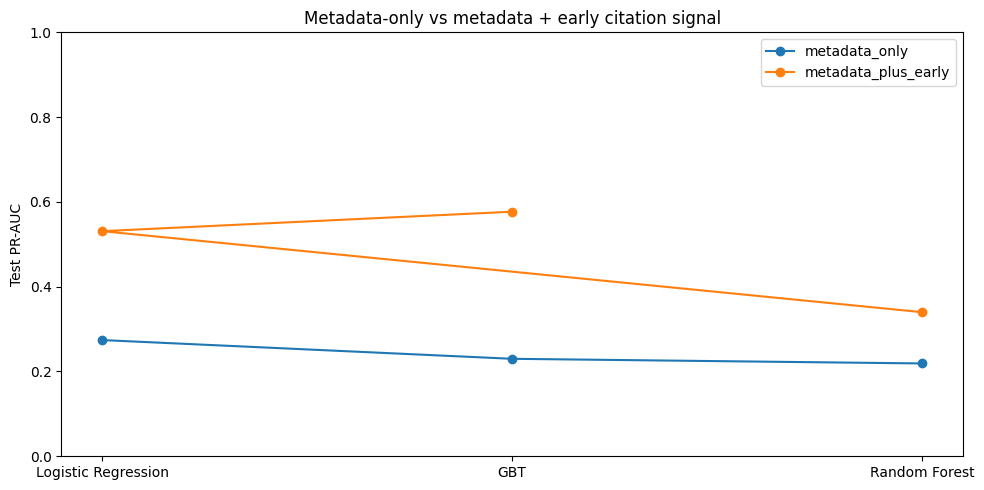

In [15]:
plt.figure(figsize=(10, 5))
for mode in summary["feature_mode"].unique():
    sub = summary[summary["feature_mode"] == mode]
    plt.plot(sub["model"], sub["test_pr_auc"], marker="o", label=mode)
plt.ylabel("Test PR-AUC")
plt.title("Metadata-only vs metadata + early citation signal")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Threshold curves (validation only)

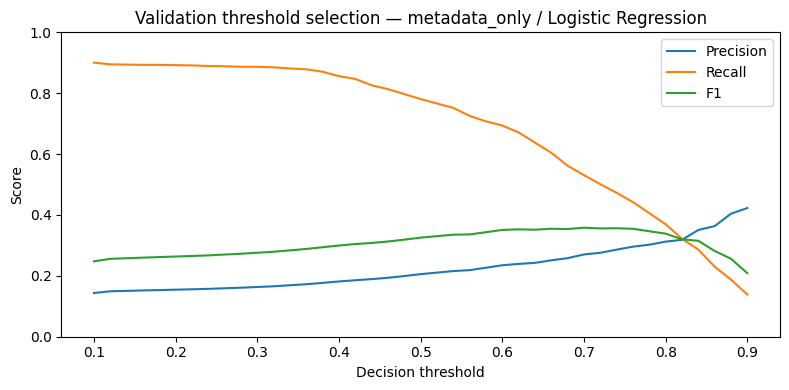

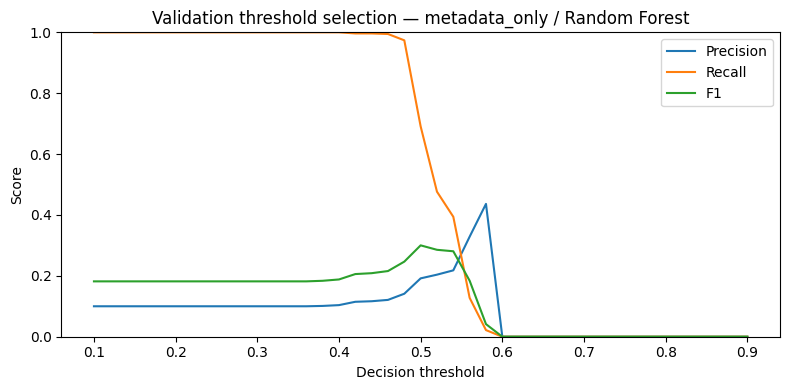

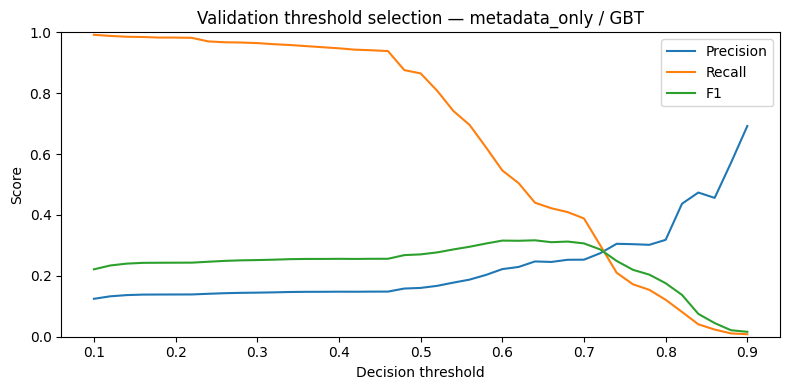

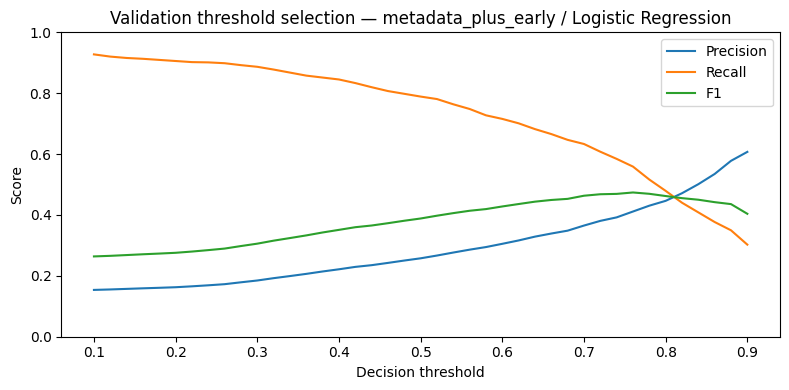

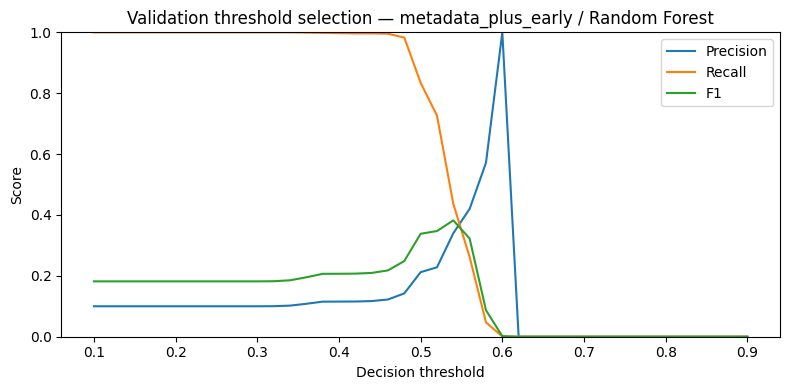

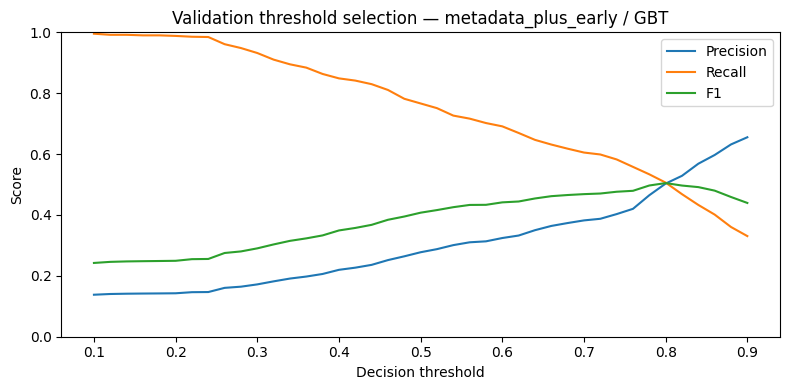

In [16]:
for key, curve in threshold_tables.items():
    plt.figure(figsize=(8, 4))
    plt.plot(curve["threshold"], curve["precision"], label="Precision")
    plt.plot(curve["threshold"], curve["recall"], label="Recall")
    plt.plot(curve["threshold"], curve["f1"], label="F1")
    plt.xlabel("Decision threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.title(f"Validation threshold selection — {key[0]} / {key[1]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 15. Feature importance


metadata_only / Random Forest


,feature,importance
0,international_collab,0.136403
1,num_countries,0.075280
2,num_institutions,0.052357
3,venue=unknown,0.032946
4,venue=Applied Energy,0.032312
5,venue=Remote Sensing of Environment,0.030644
6,venue=ISPRS Journal of Photogrammetry and Remo...,0.026796
7,venue=The Science of The Total Environment,0.026566
8,num_authors,0.026287
9,venue=DOAJ (DOAJ: Directory of Open Access Jou...,0.025675


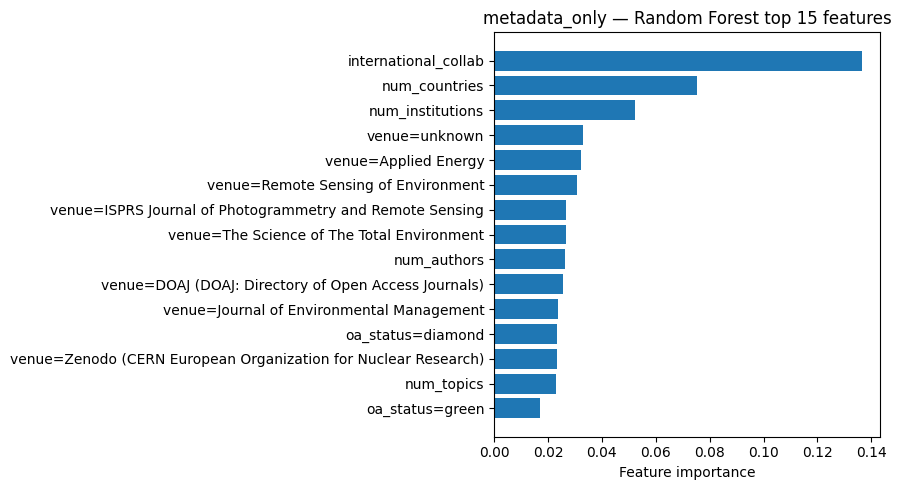


metadata_only / GBT


,feature,importance
0,num_countries,0.184843
1,num_authors,0.087994
2,num_institutions,0.053043
3,venue=Remote Sensing of Environment,0.048579
4,oa_status=green,0.042591
5,venue=The Science of The Total Environment,0.036009
6,num_topics,0.031978
7,venue=Remote Sensing,0.030960
8,venue=Journal of Cleaner Production,0.027117
9,venue=Journal of Hydrology,0.024856


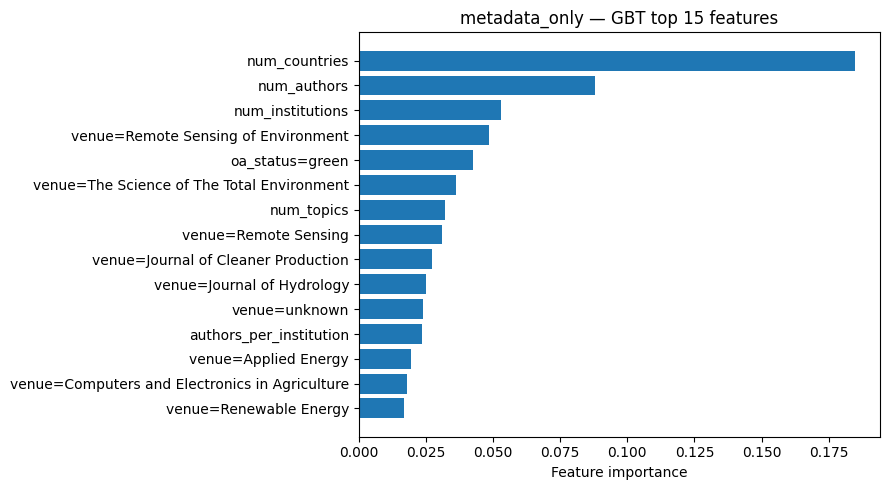


metadata_plus_early / Random Forest


,feature,importance
0,num_countries,0.102987
1,num_institutions,0.090803
2,international_collab,0.089318
3,early_calendar_year_citations,0.069528
4,venue=Remote Sensing,0.050227
5,num_topics,0.034127
6,authors_per_institution,0.024843
7,num_authors,0.021458
8,venue=DOAJ (DOAJ: Directory of Open Access Jou...,0.020450
9,oa_status=diamond,0.020345


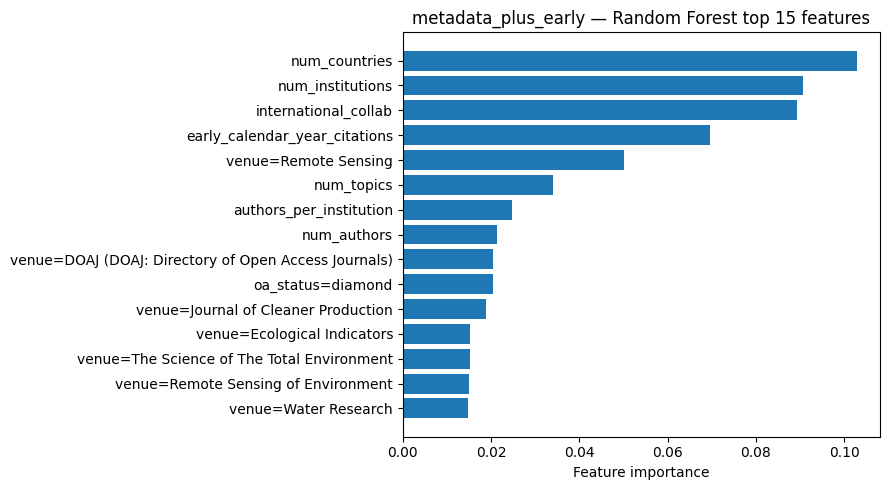


metadata_plus_early / GBT


,feature,importance
0,early_calendar_year_citations,0.321524
1,num_countries,0.101359
2,num_authors,0.075285
3,venue=Remote Sensing of Environment,0.033515
4,oa_status=green,0.026701
5,venue=Journal of Hydrology,0.026318
6,authors_per_institution,0.025966
7,venue=Remote Sensing,0.022243
8,venue=Journal of Cleaner Production,0.020308
9,venue=The Science of The Total Environment,0.020014


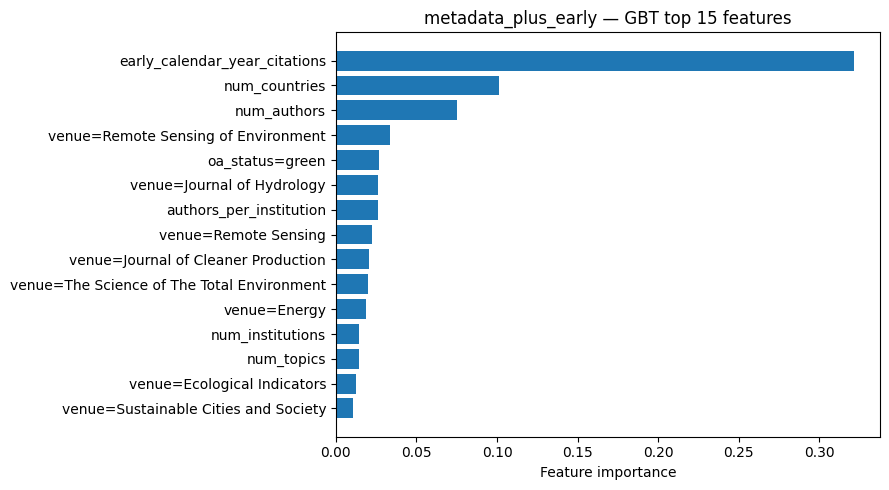

In [17]:
def feature_names_from_pipeline(prep_model, feature_mode):
    numeric = [
        "num_authors", "num_institutions", "num_countries",
        "international_collab", "authors_per_institution",
        "is_oa_int", "num_topics",
    ]
    if feature_mode == "metadata_plus_early":
        numeric.append("early_calendar_year_citations")

    venue_labels = prep_model.stages[0].labels
    oa_labels = prep_model.stages[2].labels

    # OneHotEncoder uses dropLast=True by default, so the final category is omitted.
    return (
        numeric
        + [f"venue={v}" for v in venue_labels[:-1]]
        + [f"oa_status={o}" for o in oa_labels[:-1]]
    )

importance_tables = {}

for mode, (prep, models, _, _) in results_by_mode.items():
    names = feature_names_from_pipeline(prep, mode)

    for model_name in ["Random Forest", "GBT"]:
        model = models[model_name]
        importance = model.featureImportances.toArray()

        if len(importance) != len(names):
            print(
                f"Warning: feature-name count ({len(names)}) != importance count "
                f"({len(importance)}) for {mode} / {model_name}. Truncating to the shared length."
            )

        n = min(len(importance), len(names))
        df_imp = (
            pd.DataFrame({
                "feature": names[:n],
                "importance": importance[:n],
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

        importance_tables[(mode, model_name)] = df_imp

        print(f"\n{mode} / {model_name}")
        display(df_imp.head(15))

        top = df_imp.head(15).sort_values("importance")
        plt.figure(figsize=(9, 5))
        plt.barh(top["feature"], top["importance"])
        plt.title(f"{mode} — {model_name} top 15 features")
        plt.xlabel("Feature importance")
        plt.tight_layout()
        plt.show()


## 16. Sanity checks and research interpretation

In [18]:
# Check whether early citation signal is mechanically related to the final target.
# This is expected to be predictive, but it demonstrates why it must be reported
# separately from the strict metadata-only experiment.
corr = sdf.select(
    F.corr(
        "early_calendar_year_citations",
        "cited_by_count_total",
    ).alias("pearson_corr")
).collect()[0][0]

print("Correlation between early calendar-year citations and total citations:")
print(corr)

print("\nRecommended interpretation:")
print("1) Metadata-only answers the research agenda most directly.")
print("2) Metadata + early citation signal tests whether adding an early citation signal improves prediction.")
print("3) Do not describe the second setting as metadata-only or as an exact first-12-month model.")
print("4) Report PR-AUC prominently because the high-impact class is only about 10%.")
print("5) The 2023-2024 test set remains untouched during threshold selection.")


Correlation between early calendar-year citations and total citations:
0.34174990833699753

Recommended interpretation:
1) Metadata-only answers the research agenda most directly.
2) Metadata + early citation signal tests whether adding an early citation signal improves prediction.
3) Do not describe the second setting as metadata-only or as an exact first-12-month model.
4) Report PR-AUC prominently because the high-impact class is only about 10%.
5) The 2023-2024 test set remains untouched during threshold selection.


## 17. Save paper-ready outputs

In [19]:
results_df.to_csv("improved_model_comparison_results.csv", index=False)

for (mode, model_name), df_imp in importance_tables.items():
    safe_mode = mode.replace("+", "plus")
    safe_model = model_name.lower().replace(" ", "_")
    df_imp.to_csv(f"{safe_mode}_{safe_model}_feature_importance.csv", index=False)

for (mode, model_name), curve in threshold_tables.items():
    safe_mode = mode.replace("+", "plus")
    safe_model = model_name.lower().replace(" ", "_")
    curve.to_csv(f"{safe_mode}_{safe_model}_validation_thresholds.csv", index=False)

print("Saved model results, feature importance tables, and validation threshold curves.")

Saved model results, feature importance tables, and validation threshold curves.
